In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import networkx as nx
import torch_geometric
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
from torch.nn import Linear


In [84]:
dataset = KarateClub()
data = dataset[0]

In [85]:
node_features_df = pd.DataFrame(data.x.numpy(), columns=[f"feature_{i}" for i in range(data.x.shape[1])])
node_features_df['node'] = node_features_df.index
node_features_df.set_index('node', inplace = True)

edge_index_df = pd.DataFrame(data.edge_index.numpy().T, columns = ["source", "target"])

labels_df = pd.DataFrame(data.y.numpy(), columns = ['label'])
labels_df['node'] = labels_df.index
labels_df.set_index('node', inplace = True)

In [86]:
# node_features_df

# Has all the features as one hot encoded

In [87]:
# edge_index_df.shape # => indicates total 156 edges

# edge_index_df # mentions the source node and the target node

In [88]:
# labels_df.shape 
# labels_df # indicates the country of all 34 students (value either 1,2,3 or 4 => indicating country)
# labels_df["label"].value_counts()

In [89]:
num_countries = 4

np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries, data.num_nodes))
data.y = countries


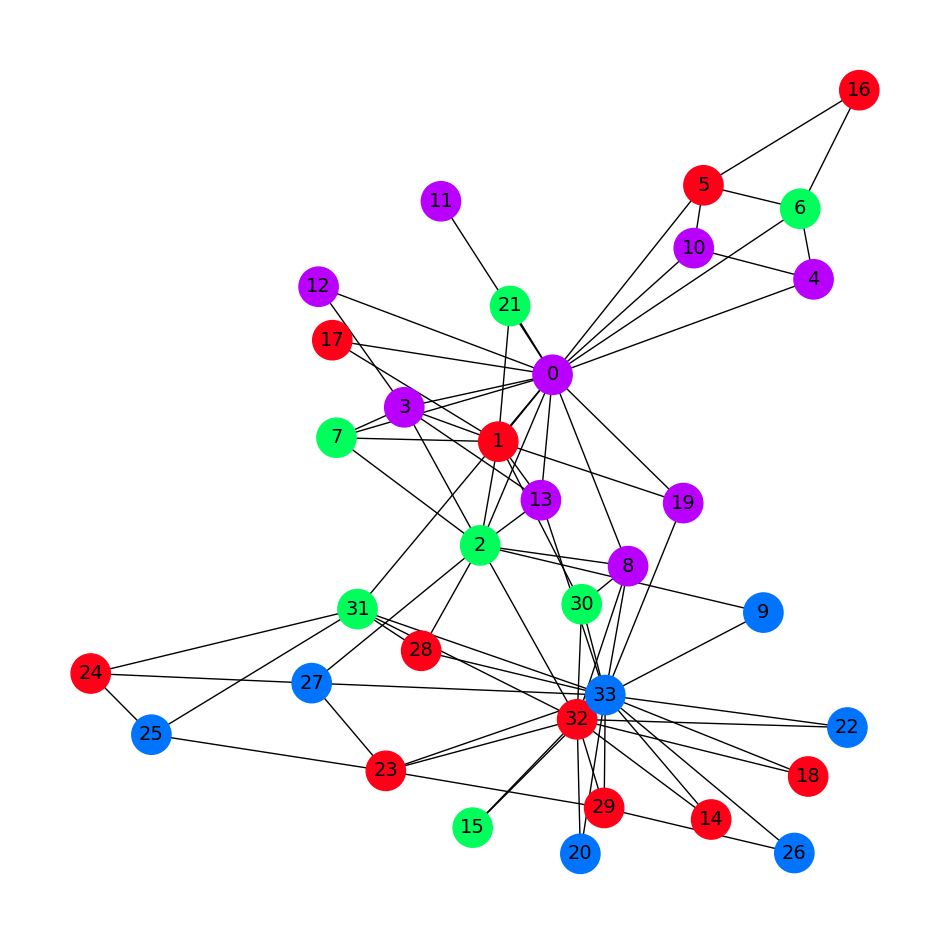

In [90]:
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G, 
                 pos=nx.spring_layout(G, method="force", seed=0), 
                 with_labels=True, 
                 node_size=800, 
                 node_color=data.y, 
                 cmap="hsv",
                 vmin = -2, 
                 vmax=3, 
                 width=1, 
                 edge_color="black", 
                 font_size=14
                 )

plt.show()